# Read H-Reflex App Data Files

This notebook reads and visualizes data from the **H-Reflex Behavior App** (hreflex_txbdc) binary data files.

**V2 file convention (current):**
- **`.hrs1`** — MH Recruitment Curve stage: sweeps across stimulation intensities to map the M/H-wave recruitment curve.
- **`.hrs2`** — Control Mode stage: stimulates at a fixed user-set intensity (can be changed between trials).
- **`.hrs3`** — Down Condition Pellet (DCP) stage: closed-loop H-reflex conditioning with pellet reward.

**V1 file convention (legacy):**
- **`.hrs1`** — EMG Characterization stage: captures baseline EMG grand-mean distribution.
- **`.hrs2`** — MH Recruitment Curve stage (same binary format as V2 `.hrs1`).

All trial files share the MhRecHeader + MhRecTrial binary format.
EMG data blocks (raw differential, filtered, abs-value) are embedded in every file.

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers
    read_hrs1, read_hrs2, read_hrs3, find_hrs_files, detect_app_version,
    # Summary printers
    print_hrs1_summary, print_hrs2_summary,
    # HRS2 plots
    plot_amplitude_distribution, plot_background_emg_views, plot_hrs2_analysis,
    # SNR analysis
    compute_snr_analysis, compute_mra_snr_analysis,
    plot_hrs2_trials, classify_trials, get_trial_window,
    detect_stim_onset, get_trial_context_window,
    detect_and_correct_failed_trials,
    # Post-hoc global windowing analysis
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    split_trials_by_polarity, plot_hm_ratio_summary, plot_hwave_regression,
    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
    build_merged_amp_groups,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: HRS1 File — EMG Characterization (V1 only)

The cells in this section apply only to **V1** recordings where `.hrs1` contains
the EMG Characterization stage. They are automatically skipped for V2 recordings.

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [2]:
recording_dir         = "C4_HRPILOT-17_BOOTH2_500US_6-24-26"
recording_sample_rate = 15000  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect from HRS1 header

hrs1_path, hrs2_path, hrs3_path = find_hrs_files(recording_dir)
_app_version = detect_app_version(recording_dir)
print(f"H-Reflex App V{_app_version}  |  "
      f"hrs1={os.path.basename(hrs1_path) if hrs1_path else chr(8211)}  "
      f"hrs2={os.path.basename(hrs2_path) if hrs2_path else chr(8211)}  "
      f"hrs3={os.path.basename(hrs3_path) if hrs3_path else chr(8211)}")


H-Reflex App V2  |  hrs1=–  hrs2=C4_HRPILOT-17_BOOTH2_500US_6-24-26_20260624T110546.hrs2  hrs3=–


In [3]:
# --- Load all data files (auto-detects V1 / V2 app) ---------------------------
cm_header  = cm_trials  = cm_emg_blocks  = None   # V2 Control Mode (None in V1)
dcp_header = dcp_trials = dcp_emg_blocks = None   # V2 Down Condition Pellet (None in V1)

if _app_version == 1:
    # V1: S1=EMG Characterization (.hrs1)  S2=MH Recruitment Curve (.hrs2)
    if hrs1_path:
        hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
        print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — EMG Characterization data unavailable.")
        hrs1_header, hrs1_trials, hrs1_emg_blocks = None, [], []
    if hrs2_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)
    else:
        print("No .hrs2 file found — MH Recruitment data unavailable.")
        hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    # V2: S1=MH Recruitment (.hrs1, same binary as V1 .hrs2)
    #     S2=Control Mode (.hrs2)   S3=Down Condition Pellet (.hrs3)
    if hrs1_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs1_path)
        hrs1_header = hrs2_header          # alias — no separate EMG char stage in V2
        hrs1_trials, hrs1_emg_blocks = [], []
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — MH Recruitment data unavailable.")
        hrs1_header = hrs2_header = None
        hrs1_trials = hrs2_trials = []
        hrs1_emg_blocks = hrs2_emg_blocks = []
    if hrs2_path:
        cm_header, cm_trials, cm_emg_blocks = read_hrs2(hrs2_path)
        print(f"Control Mode:           {len(cm_trials)} trials")
    else:
        print("No .hrs2 file found — Control Mode data unavailable.")
    if hrs3_path:
        dcp_header, dcp_trials, dcp_emg_blocks = read_hrs3(hrs3_path)
        print(f"Down Condition Pellet:  {len(dcp_trials)} trials")
    else:
        print("No .hrs3 file found — Down Condition Pellet data unavailable.")


# V2 Control Mode-only: no Recruitment Curve stage (.hrs1 absent).
# Alias hrs2_trials <- cm_trials so all downstream analysis cells work unchanged.
if _app_version == 2 and not hrs2_trials and cm_trials:
    hrs2_header     = cm_header
    hrs2_trials     = cm_trials
    hrs2_emg_blocks = cm_emg_blocks
    hrs1_header     = hrs2_header
    print('Note: Control Mode trials used as primary analysis (no Recruitment Curve stage).')

# Ensure hrs1_header.sample_rate is always accessible for downstream cells
if hrs1_header is None:
    class _SampleRateStub:
        sample_rate = recording_sample_rate or 5000.0
    hrs1_header = _SampleRateStub()


No .hrs1 file found — MH Recruitment data unavailable.
Control Mode:           209 trials
No .hrs3 file found — Down Condition Pellet data unavailable.
Note: Control Mode trials used as primary analysis (no Recruitment Curve stage).


# Section 3: Peri-Stimulus Trials — MH Recruitment Curve or Control Mode

For **V2** recordings `hrs2_trials` contains whichever stage was run:
- `.hrs1` present → MH Recruitment Curve trials
- `.hrs1` absent, `.hrs2` present → Control Mode trials (aliased automatically)

For **V1** recordings `hrs2_trials` contains the MH Recruitment Curve trials from `.hrs2`.

In [4]:
# Data already loaded in the cell above.
# hrs2_trials = MH Recruitment Curve trials (V1 or V2).
print(f"MH Recruitment trials : {len(hrs2_trials)}"
      + (f"  |  Control Mode: {len(cm_trials)}" if cm_trials  is not None else "")
      + (f"  |  DCP: {len(dcp_trials)}"         if dcp_trials is not None else ""))


MH Recruitment trials : 209  |  Control Mode: 209


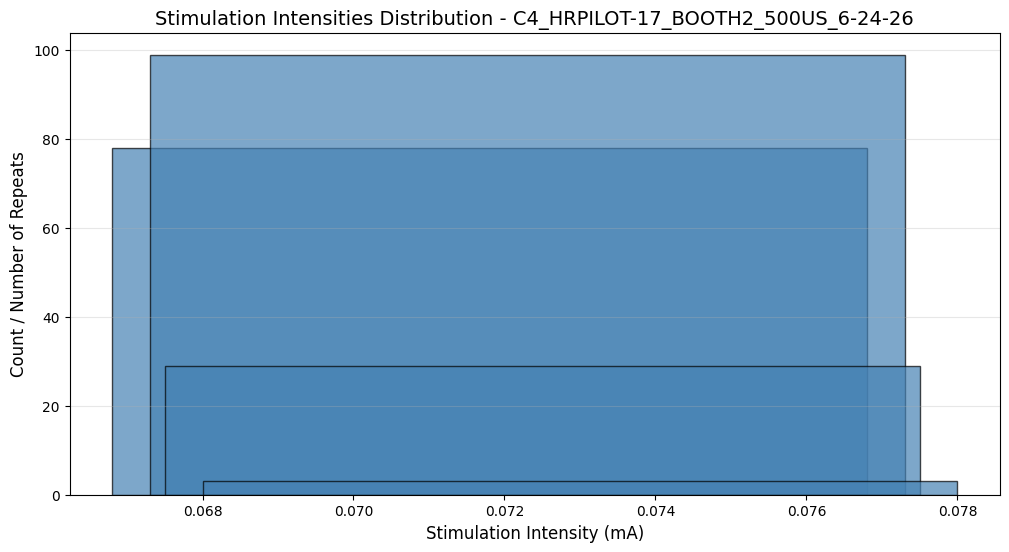

In [5]:
# ---- Histogram of stimulation intensities ----
plot_amplitude_distribution(hrs2_trials, hrs2_header)

# Section 3b: "Most Recent Background" + "Background EMG Level"

Recreates the H-Reflex App recruitment-curve trial-plot widgets from `MhRecruitmentCurveStage.get_trial_plot_options`:

- **Most recent background** â€” bar chart of the pre-stim |EMG| bins.
- **EMG Level** â€” scatter of background grand means across trials.

Bins are reconstructed from `hrs2_emg_blocks` over a fixed monitoring window (default 2500 ms ending at trigger time).

In [6]:
# ---- "Most recent background" + "Background EMG Level" plots ----
# Mirrors the H-Reflex App recruitment-curve trial plot widgets.
plot_background_emg_views(hrs2_trials, hrs2_emg_blocks, monitoring_window_ms=2500)

207 trials used stored bins  |  2 trials reconstructed from emg_blocks.


# Section 6: HRS2 Detailed Analysis

Interactive averaged-waveform paged grid (with M/H peak markers and signal overlays) plus the normalized and raw recruitment curves. The cell below sets the analysis parameters; the cell after that calls `plot_hrs2_analysis`.

In [7]:
#  Configuration 
PRE_PLOT_MS  = 5   # ms before stim onset to display
POST_PLOT_MS = 25  # ms after  stim onset to display
N_PER_PAGE   = 6   # trials shown per page (2 rows x 3 cols)

# M/H wave window constants (ms relative to stim onset)
#M_WAVE_START_MS = 3
#M_WAVE_END_MS= 5.5
#H_WAVE_START_MS = 9.0
#H_WAVE_END_MS   = 12

M_WAVE_START_MS = 1.8 
M_WAVE_END_MS= 5 
H_WAVE_START_MS = 7
H_WAVE_END_MS   = 12

PRE_AVG_MS  = 5   # ms before stim onset
POST_AVG_MS = 25  # ms after  stim onset
N_PER_PAGE  = 6   # amplitude groups per page (2 rows x 3 cols)


In [8]:
# ── Optional: Merged Amplitude Group Analysis ─────────────────────────────
# Pool multiple stimulation intensities into one merged group.
# MERGED_GROUPS is a list of lists, e.g.:
#   [[0.12, 0.13], [0.15, 0.16, 0.17]]  →  two merged groups
# Leave as [] to use the default (unmerged) grouping.
MERGED_GROUPS = []

if MERGED_GROUPS:
    _hrs2_trials_plot = build_merged_amp_groups(hrs2_trials, MERGED_GROUPS)
else:
    _hrs2_trials_plot = hrs2_trials


In [9]:
# ---- HRS2 Analysis: Interactive Averaged Waveforms + Recruitment Curve ----
plot_hrs2_analysis(
    _hrs2_trials_plot, hrs2_header,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    emg_blocks=hrs2_emg_blocks,
)

Loaded 4 amplitude groups across 1 page(s).
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


Output()

HTML(value='<hr><b>Background EMG — selected amplitude / polarity group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected amplitude / polarity group</b>')

Output()

In [10]:
# ---- HRS2 Trial Viewer: Interactive Per-Trial Grid + Zoom ----
plot_hrs2_trials(
    _hrs2_trials_plot, hrs2_header,
    pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    emg_blocks=hrs2_emg_blocks,
)

Loaded 209 trials across 35 page(s).
Sample rate: 15000 Hz  |  ms/sample: 0.0667
Stim waveform: available
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


HTML(value='<hr><b>Background EMG — selected group</b>')

Output()

HTML(value='<hr><b>H:M Ratio Summary — selected group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected group</b>')

Output()

# Section 3c: H:M Ratio Summary

Box plot and histogram of H:M ratio for each stimulation polarity group.
If both normal and reversed polarities were used in this session, each group is analysed separately.

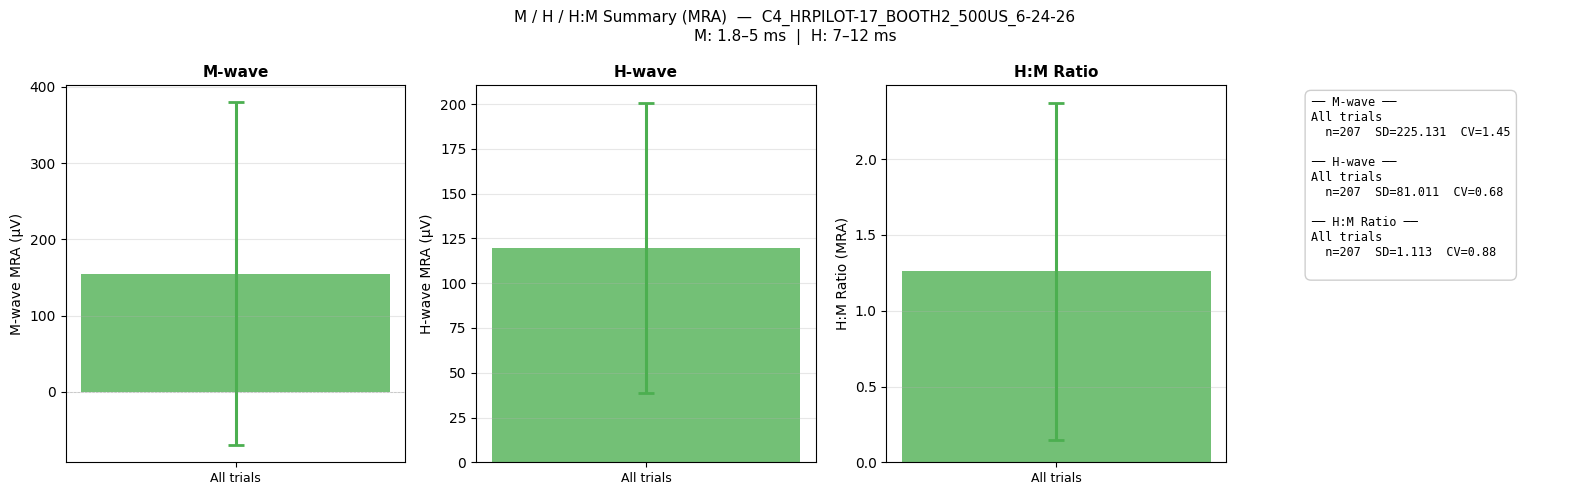

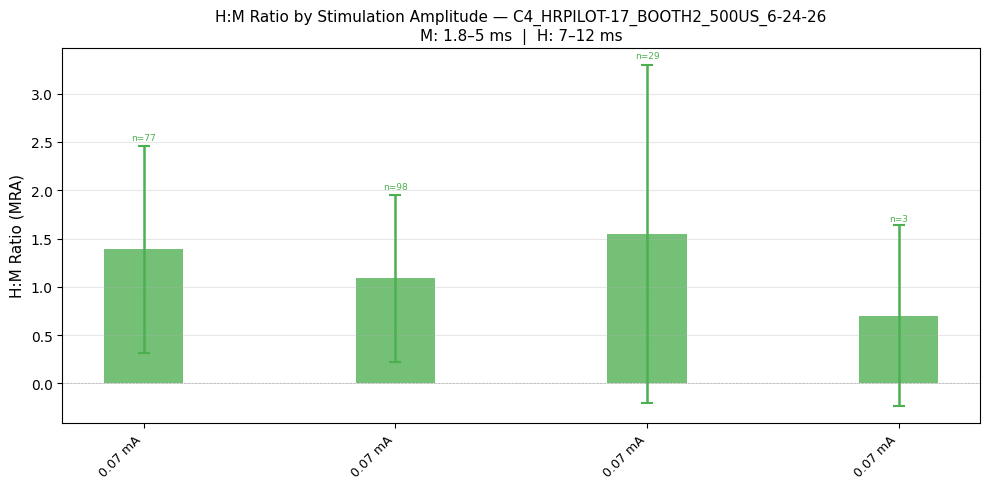

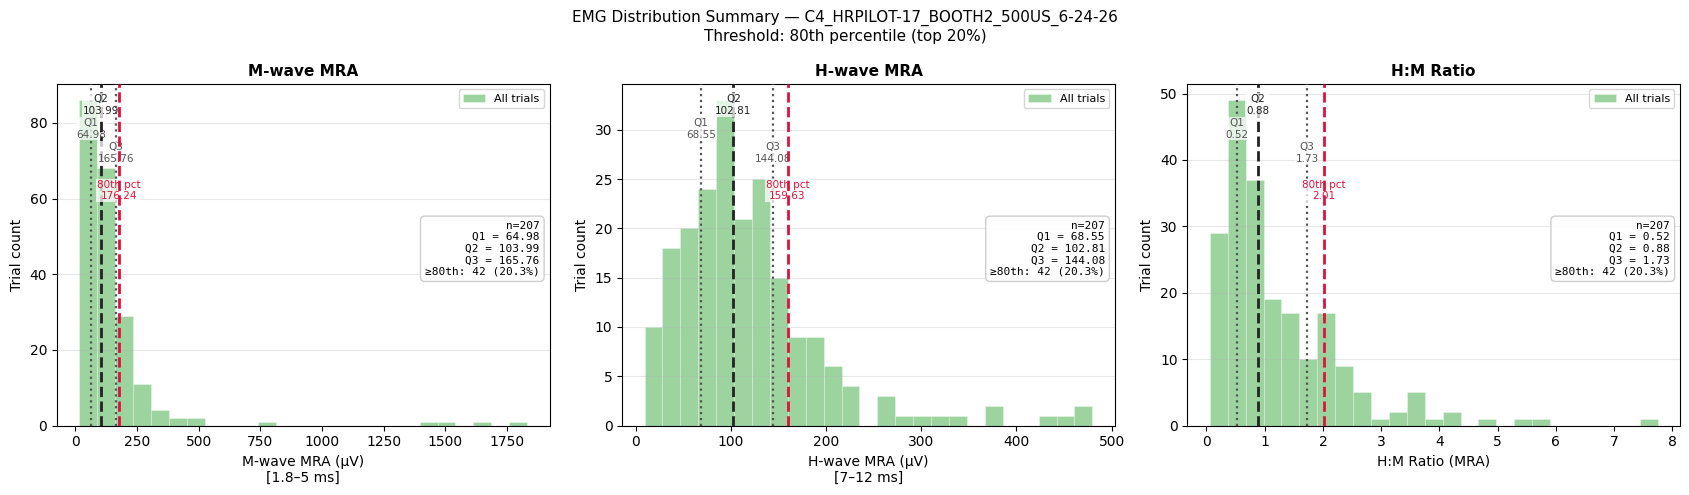

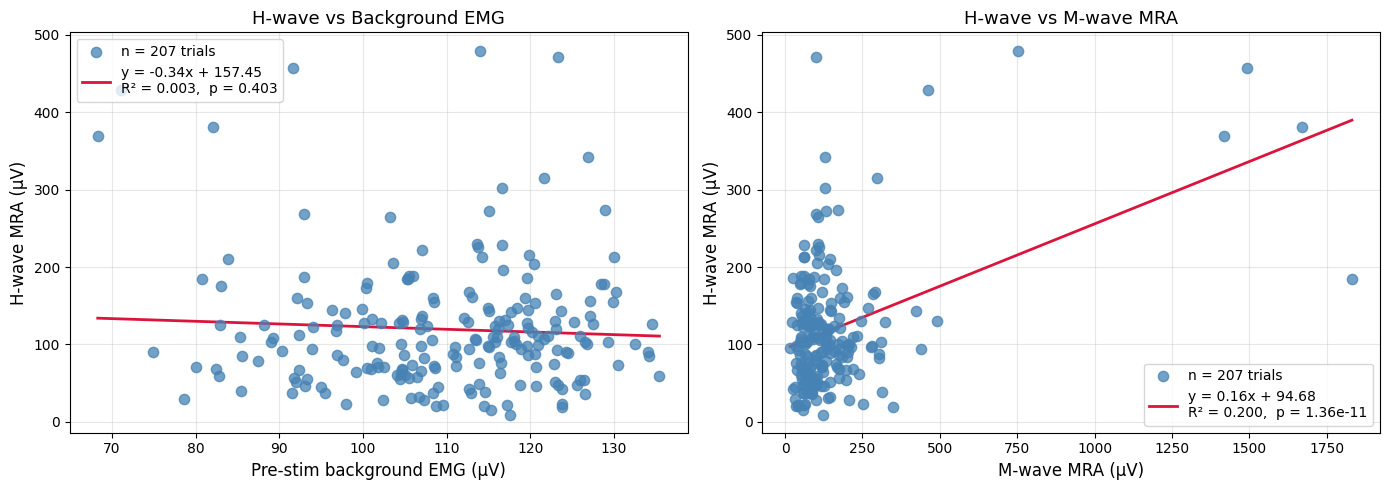

  Regression (n=207):  slope=-0.3447  intercept=157.45  R²=0.0034  p=0.4034


In [11]:
# ---- Stim polarity split ----
trials_by_polarity = split_trials_by_polarity(hrs2_trials)

# ---- H:M Ratio Summary: box plot + histogram ----
plot_hm_ratio_summary(
    trials_by_polarity, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
)
# ---- H-wave Regression: H-wave amplitude vs background EMG ----
plot_hwave_regression(
    hrs2_trials, hrs2_emg_blocks,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
)

# Section 7: Signal-to-Noise Ratio Analysis

For each trial three RMS-based SNR values are computed relative to the **RMS of the 15 ms pre-stimulus background**:

| SNR metric | Formula |
|---|---|
| **SNR_M** | RMS(M-wave window) / RMS(15 ms pre-stim BG) |
| **SNR_H** | RMS(H-wave window) / RMS(15 ms pre-stim BG) |
| **SNR_H:M** | (RMS_H / RMS_M) / RMS(15 ms pre-stim BG) |

M and H windows use the same time boundaries defined in Section 6 above.  
Adjust `BG_PRE_MS` below to change the background window length.

SNR Analysis — C4_HRPILOT-17_BOOTH2_500US_6-24-26
  M window : 1.8–5 ms
  H window : 7–12 ms
  BG window: -15–0 ms (pre-stim)

Metric                 n      Mean    Median        SD      CV
--------------------------------------------------------------
  SNR_M  (M/BG)      207     1.589     1.004     2.743   1.726
  SNR_H  (H/BG)      207     1.288     0.975     1.091   0.847
  SNR_HM (H:M/BG)    207     0.013     0.008     0.024   1.887


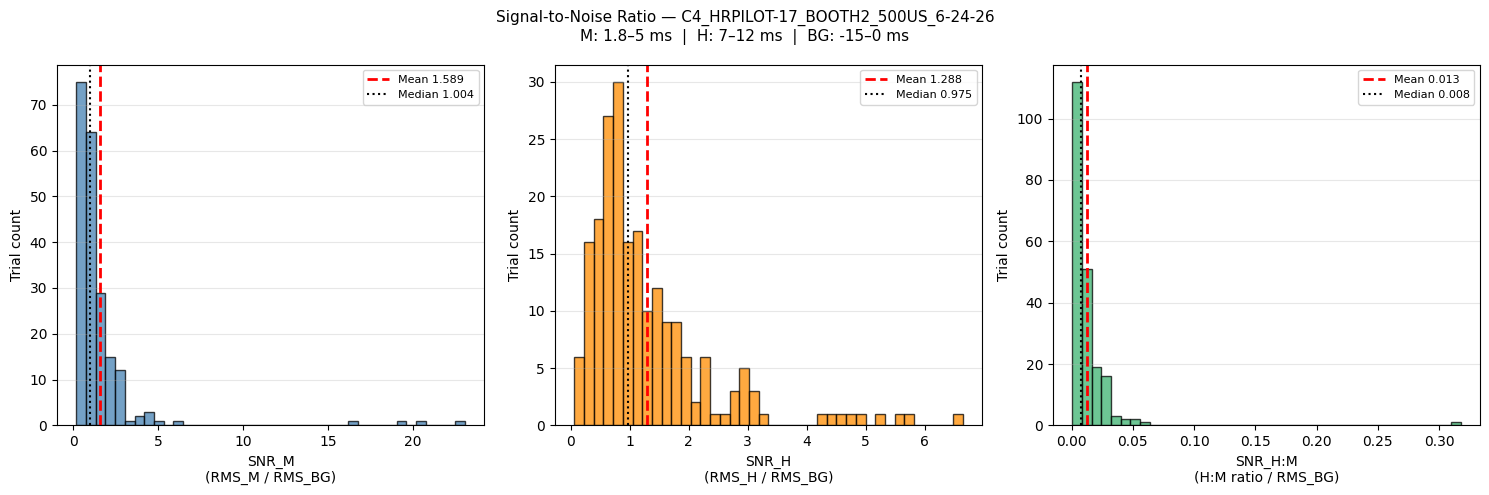

In [12]:
# ---- Section 7: Signal-to-Noise Ratio ----
# Background window length (ms before stim onset). Default = 15 ms.
BG_PRE_MS = 15.0

snr_results = compute_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 8: Signal-to-Noise Ratio Analysis (Mean Rectified Average)

Same SNR analysis as Section 7, but using **Mean Rectified Average (MRA)** â€” `mean(|signal|)` â€” instead of RMS for all measurements.

| SNR metric | Formula |
|---|---|
| **MRA-SNR_M** | MRA(M-wave window) / MRA(15 ms pre-stim BG) |
| **MRA-SNR_H** | MRA(H-wave window) / MRA(15 ms pre-stim BG) |
| **MRA-SNR_H:M** | (MRA_H / MRA_M) / MRA(15 ms pre-stim BG) |

MRA-SNR Analysis — C4_HRPILOT-17_BOOTH2_500US_6-24-26
  M window : 1.8–5 ms
  H window : 7–12 ms
  BG window: -15–0 ms (pre-stim)

Metric                   n      Mean    Median        SD      CV
----------------------------------------------------------------
  MRA-SNR_M  (M/BG)    207     1.783     1.118     3.102   1.740
  MRA-SNR_H  (H/BG)    207     1.383     1.009     1.200   0.867
  MRA-SNR_HM (H:M/BG)   207     0.016     0.009     0.030   1.868


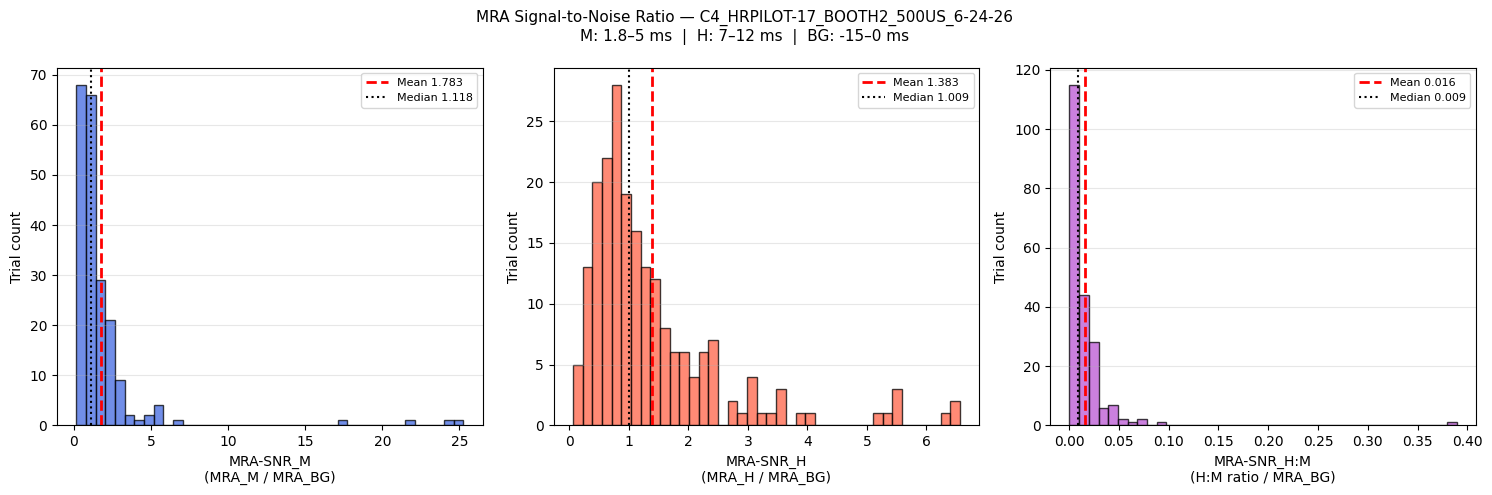

In [13]:
# ---- Section 8: MRA Signal-to-Noise Ratio ----
# Background window length (ms before stim onset). Default = 15 ms.
BG_PRE_MS = 15.0

mra_snr_results = compute_mra_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)